## Analysis 2: Phenotype-level Consistency (Kendall's W + Cross-profile Rank Correlation)

The goal is to determine whether gene rankings are driven by the specific phenotypic profile being queried, or whether the same genes tend to rank highly across all profiles regardless of phenotype (which would indicate a systematic scoring bias). (in short, different phenotype should have different rankings in genetic perturbations.)


We use: 
- **Kendall's W**: a coefficient of concordance over the *k* = 16 phenotypes and *n* shared treatment
  - This measures how consistent genes are ranked across all 16 phenotypes
  - W = 0 → profiles rank genes completely independently (rankings are profile-specific, the ideal outcome for distinct phenotypes).  
  - W = 1 → all profiles rank genes in exactly the same order (systematic bias; a gene that ranks #1 for Anaphase also ranks #1 for Interphase, which is biologically implausible).  
  - Values in between indicate partial concordance; moderate W with a structured correlation matrix suggests biological sub-clusters rather than noise.

- **Cross-profile Spearman ρ matrix** — pairwise rank correlation between every pair of profiles.  
  - This measures whether two profiles rank genes differently, as expected if buscar is capturing distinct phenotypic signals
  - Positive ρ (blue) → the two profiles tend to promote the same genes, suggesting shared biology or other features that are in common.  
  - Negative ρ (red) → genes that are top hits for one profile rank poorly for the other — strong evidence of profile-specific signal.  
  - Near-zero ρ (white) → rankings are essentially independent between those two profiles.

A well-behaved analysis should show negative or near-zero off-diagonal correlations between biologically distinct profiles (e.g., Interphase vs. Prometaphase), and modest positive correlations only between phenotypically similar profiles (e.g., Metaphase and Prometaphase, or Anaphase and Apoptosis).

In [12]:
suppressPackageStartupMessages({
    library(arrow)
    library(dplyr)
    library(tidyr)
    library(ggplot2)
    library(pheatmap)
    library(grid)
})

options(warn = -1)

In [13]:
# Input data directory
results_dir <- normalizePath('../results/moa_analysis', mustWork = TRUE)

# Output directory for this notebook's figures/tables
gene_rel_dir <- normalizePath(file.path(getwd(), 'all-plots', 'gene-ranking-relationships'), mustWork = FALSE)
dir.create(gene_rel_dir, recursive = TRUE, showWarnings = FALSE)

In [14]:
# Load real and shuffled BuSCaR outputs
moa_results_df <- read_parquet(file.path(results_dir, 'original_mitocheck_moa_analysis_results.parquet')) %>% as_tibble()
shuffled_moa_results_df <- read_parquet(file.path(results_dir, 'shuffled_mitocheck_moa_analysis_results.parquet')) %>% as_tibble()

# Recompute rank within each phenotype to avoid duplicate/missing rank values.
# Lower on/off score is better, so rows are sorted accordingly before row_number().
rerank_by_profile <- function(input_df) {
  input_df %>%
    arrange(ref_profile, is.na(on_score), on_score, is.na(off_score), off_score, treatment) %>%
    group_by(ref_profile) %>%
    mutate(rank = row_number()) %>%
    ungroup()
}

moa_results_df <- rerank_by_profile(moa_results_df)
shuffled_moa_results_df <- rerank_by_profile(shuffled_moa_results_df)

head(moa_results_df)

rank,ref_profile,treatment,on_score,off_score,proportion
<int>,<chr>,<chr>,<dbl>,<dbl>,<dbl>
1,ADCCM,RGR,1.833659e-14,0,0.43055556
2,ADCCM,OGG1,1.136868e-13,0,0.04255319
3,ADCCM,CDK4,2.148890e+02,0,0.00000000
4,ADCCM,ENSG00000175216,2.164150e+02,0,0.00000000
5,ADCCM,CDKL5,2.197899e+02,0,0.00000000
6,ADCCM,LCK,2.241264e+02,0,0.00000000


In [15]:
# Keep rows where both on_score and off_score are present
prepare_df <- function(results_df) {
  results_df %>%
    as.data.frame() %>%
    filter(!is.na(on_score), !is.na(off_score))
}

df <- prepare_df(moa_results_df)
shuf_df <- prepare_df(shuffled_moa_results_df)

In [16]:
build_rank_bundle <- function(input_df) {
  rank_pivot <- input_df %>%
    select(ref_profile, treatment, rank) %>%
    pivot_wider(names_from = ref_profile, values_from = rank)

  rank_pivot_complete <- rank_pivot %>% drop_na()

  rank_pivot_reranked <- rank_pivot_complete %>%
    select(-treatment) %>%
    mutate(across(everything(), ~ rank(.x, ties.method = 'average')))

  # Use sparse, profile-wise rank matrix for pairwise correlations.
  # This avoids collapsing to ~1 treatment for shuffled data after complete-case filtering.
  rank_matrix_sparse <- rank_pivot %>%
    select(-treatment) %>%
    mutate(across(everything(), ~ rank(.x, ties.method = 'average', na.last = 'keep')))

  list(
    rank_pivot = rank_pivot,
    rank_pivot_complete = rank_pivot_complete,
    rank_pivot_reranked = rank_pivot_reranked,
    rank_matrix_sparse = rank_matrix_sparse,
    n_subjects = nrow(rank_pivot_reranked),
    k_raters = ncol(rank_pivot_reranked),
    profile_names = colnames(rank_matrix_sparse)
  )
}

orig_bundle <- build_rank_bundle(df)
shuf_bundle <- build_rank_bundle(shuf_df)

This analysis first measures global agreement in gene rankings across all phenotypes using Kendall's W. It then computes pairwise Spearman correlations between phenotype-specific gene rankings and visualizes them as a heatmap. Together, these metrics show whether ranking patterns are phenotype-specific or reflect a shared global trend.

[original] Kendall's W = 0.312
[original] complete-case n = 32, k = 16
[original] χ²(31) = 154.7386,  p = 2.2230e-18
[original] Saved -> /home/erikserrano/Projects/buscar/notebooks/3.mitocheck-analysis/plots/all-plots/gene-ranking-relationships/profile_rank_consistency.png
[shuffled] Kendall's W = 0.507
[shuffled] complete-case n = 32, k = 16
[shuffled] χ²(31) = 251.2315,  p = 2.5694e-36
[shuffled] Saved -> /home/erikserrano/Projects/buscar/notebooks/3.mitocheck-analysis/plots/all-plots/gene-ranking-relationships/shuffled_profile_rank_consistency.png


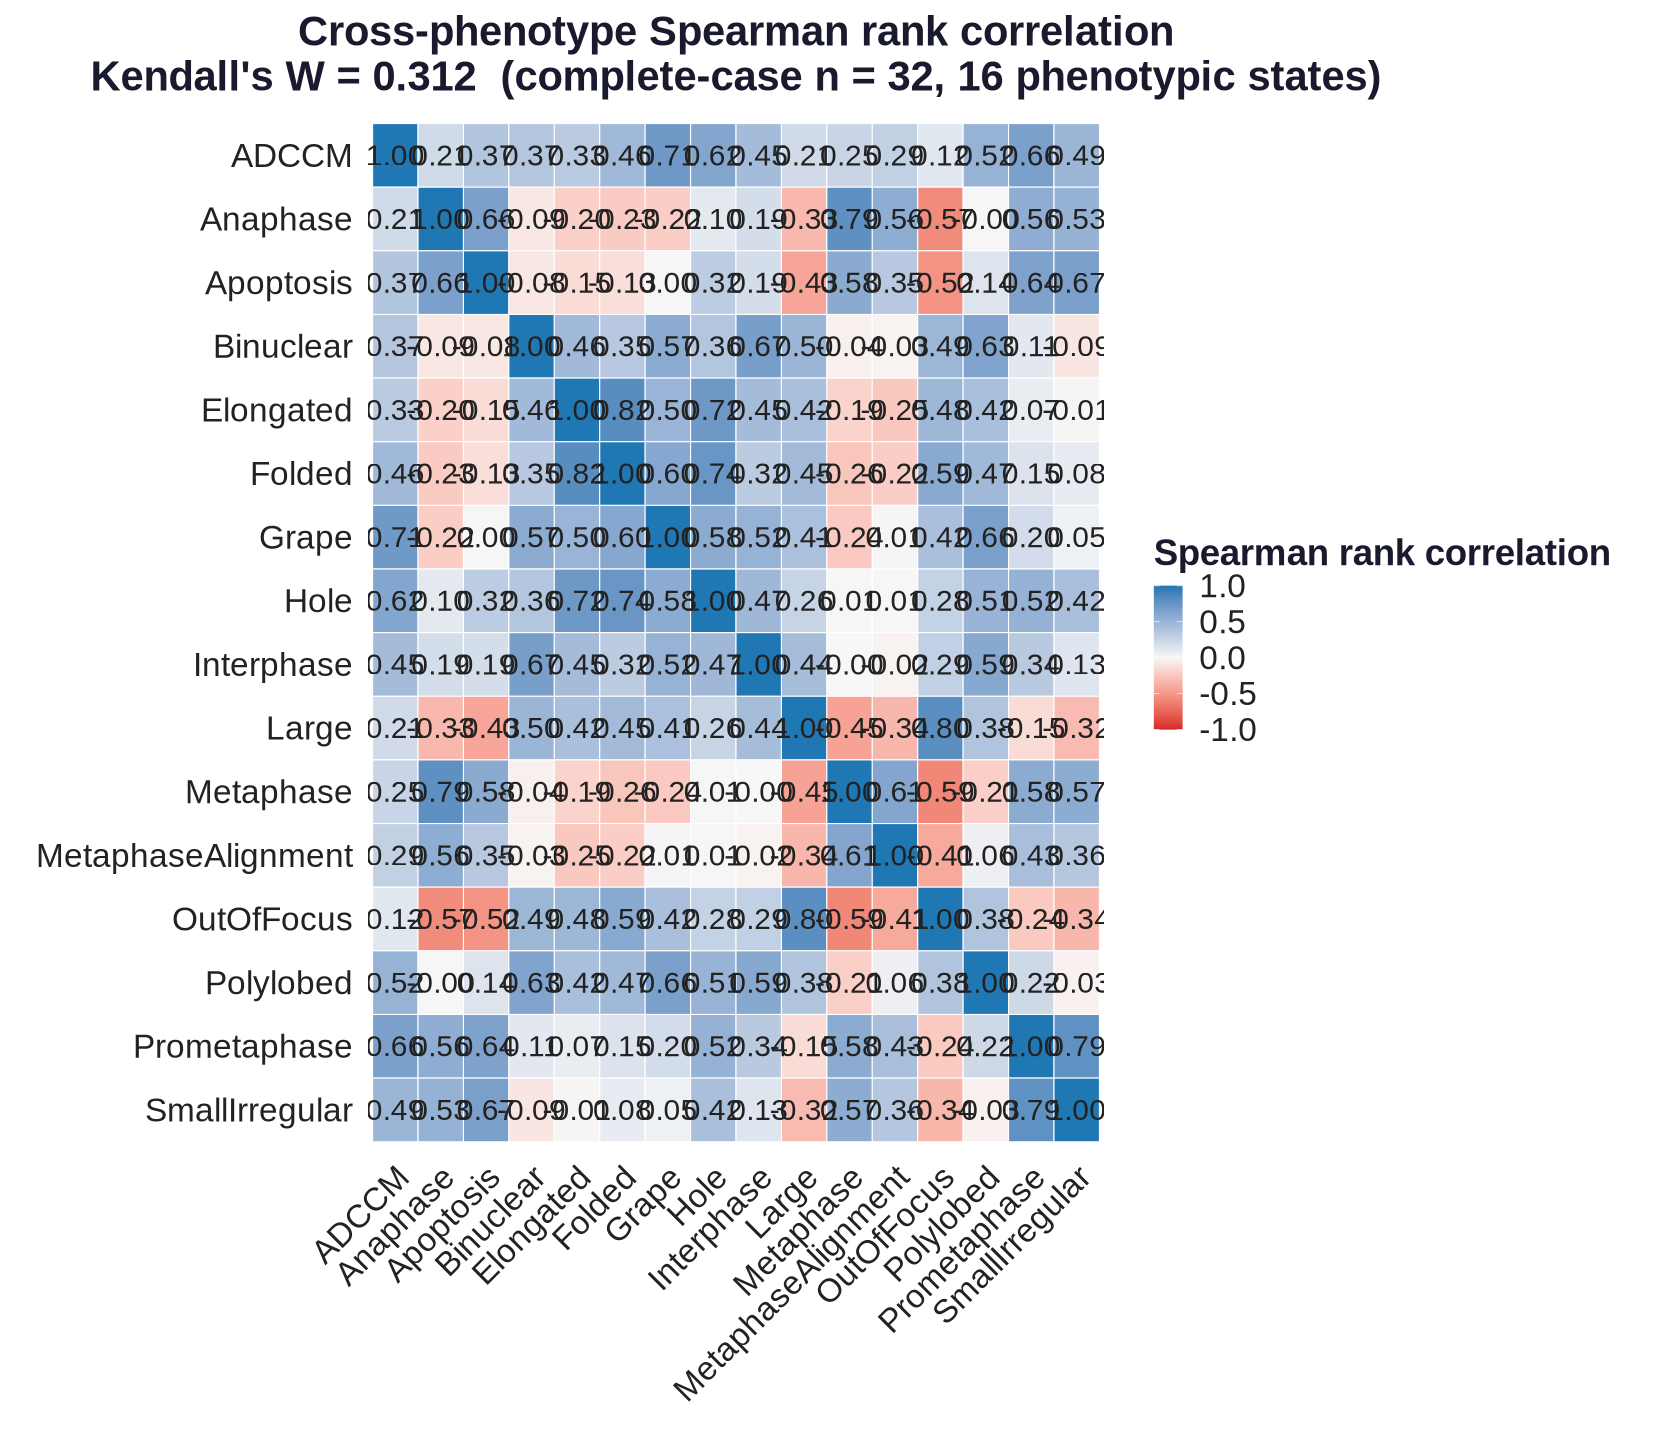

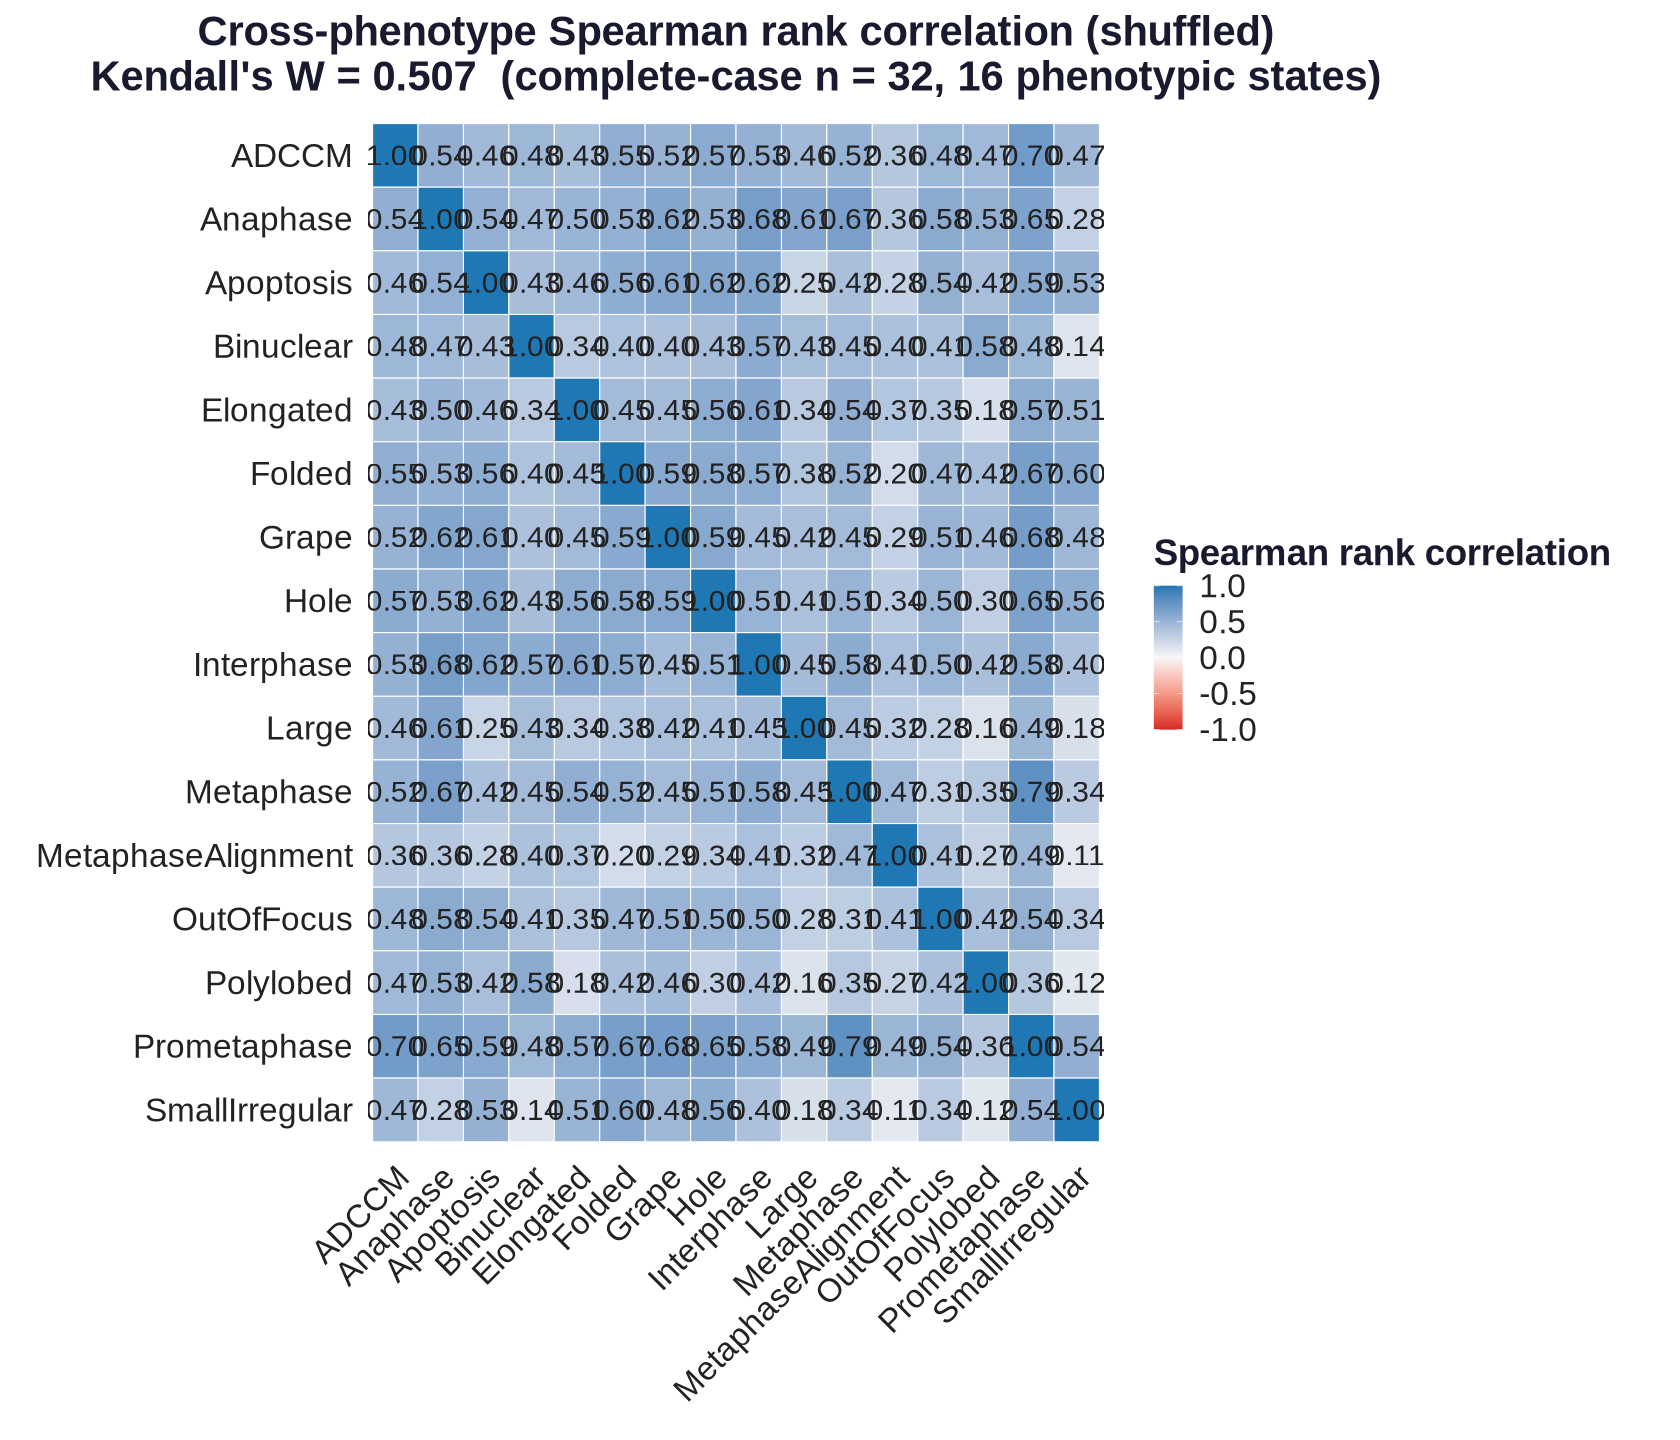

In [17]:
# options for rendering the figure larger
height <- 12
width <- 14
options(repr.plot.width = width, repr.plot.height = height)

compute_consistency <- function(bundle) {
  R_complete <- as.matrix(bundle$rank_pivot_reranked)

  if (nrow(R_complete) > 1 && ncol(R_complete) > 1) {
    rank_sums <- rowSums(R_complete)
    S <- sum((rank_sums - mean(rank_sums))^2)
    W <- (12 * S) / (bundle$k_raters^2 * (bundle$n_subjects^3 - bundle$n_subjects))
    chi2_stat <- bundle$k_raters * (bundle$n_subjects - 1) * W
    chi2_pval <- pchisq(chi2_stat, df = bundle$n_subjects - 1, lower.tail = FALSE)
    w_label <- sprintf('%.3f', W)
  } else {
    W <- NA_real_
    chi2_stat <- NA_real_
    chi2_pval <- NA_real_
    w_label <- 'NA (insufficient complete-case treatments)'
  }

  # Pairwise correlation on sparse rank matrix preserves shuffled information.
  # This avoids collapsing to ~1 treatment for shuffled data after complete-case filtering.
  R_sparse <- as.matrix(bundle$rank_matrix_sparse)
  corr_matrix <- cor(R_sparse, method = 'spearman', use = 'pairwise.complete.obs')

  diag(corr_matrix) <- 1
  corr_long <- as.data.frame(as.table(corr_matrix))
  colnames(corr_long) <- c('y', 'x', 'rho')
  corr_long$x <- factor(corr_long$x, levels = bundle$profile_names)
  corr_long$y <- factor(corr_long$y, levels = rev(bundle$profile_names))

  list(
    W = W,
    w_label = w_label,
    chi2_stat = chi2_stat,
    chi2_pval = chi2_pval,
    corr_matrix = corr_matrix,
    corr_long = corr_long,
    n_subjects = bundle$n_subjects,
    k_raters = bundle$k_raters
  )
}

plot_corr_heatmap <- function(consistency, title_suffix = '') {
  ggplot(consistency$corr_long, aes(x = x, y = y, fill = rho)) +
    geom_tile(color = 'white', linewidth = 0.3) +
    geom_text(aes(label = ifelse(is.na(rho), 'NA', sprintf('%.2f', rho))), size = 6.3, color = '#222222') +
    scale_fill_gradient2(
      low = '#d62728',
      mid = '#f7f7f7',
      high = '#1f77b4',
      midpoint = 0,
      limits = c(-1, 1),
      na.value = 'grey80'
    ) +
    labs(
      title = sprintf(
        "Cross-phenotype Spearman rank correlation%s\nKendall's W = %s  (complete-case n = %d, %d phenotypic states)",
        title_suffix, consistency$w_label, consistency$n_subjects, consistency$k_raters
      ),
      x = NULL,
      y = NULL,
      fill = 'Spearman rank correlation'
    ) +
    theme_minimal(base_size = 20) +
    theme(
      plot.title = element_text(face = 'bold', size = 25, hjust = 0.5, color = '#1a1a2e'),
      axis.text.x = element_text(angle = 45, hjust = 1, size = 20, color = '#222222'),
      axis.text.y = element_text(size = 20, color = '#222222'),
      legend.title = element_text(face = 'bold', size = 22, color = '#1a1a2e'),
      legend.text = element_text(size = 20, color = '#222222'),
      panel.grid = element_blank()
    )
}

save_and_print_corr <- function(consistency, file_name, title_suffix = '', label = 'original') {
  cat(sprintf("[%s] Kendall's W = %s\n", label, consistency$w_label))
  cat(sprintf('[%s] complete-case n = %d, k = %d\n', label, consistency$n_subjects, consistency$k_raters))

  if (!is.na(consistency$chi2_stat)) {
    cat(sprintf('[%s] χ²(%d) = %.4f,  p = %.4e\n', label, consistency$n_subjects - 1, consistency$chi2_stat, consistency$chi2_pval))
  }

  p_corr <- plot_corr_heatmap(consistency, title_suffix)
  out_path <- file.path(gene_rel_dir, file_name)
  ggsave(out_path, p_corr, width = width, height = height, dpi = 300, bg = 'white')
  cat(sprintf('[%s] Saved -> %s\n', label, out_path))
  print(p_corr)
}

orig_consistency <- compute_consistency(orig_bundle)
shuf_consistency <- compute_consistency(shuf_bundle)

save_and_print_corr(
  orig_consistency,
  'profile_rank_consistency.png',
  '',
  'original'
)

save_and_print_corr(
  shuf_consistency,
  'shuffled_profile_rank_consistency.png',
  ' (shuffled)',
  'shuffled'
)

[original] Saved -> /home/erikserrano/Projects/buscar/notebooks/3.mitocheck-analysis/plots/all-plots/gene-ranking-relationships/profile_rank_consistency_clustermap.png


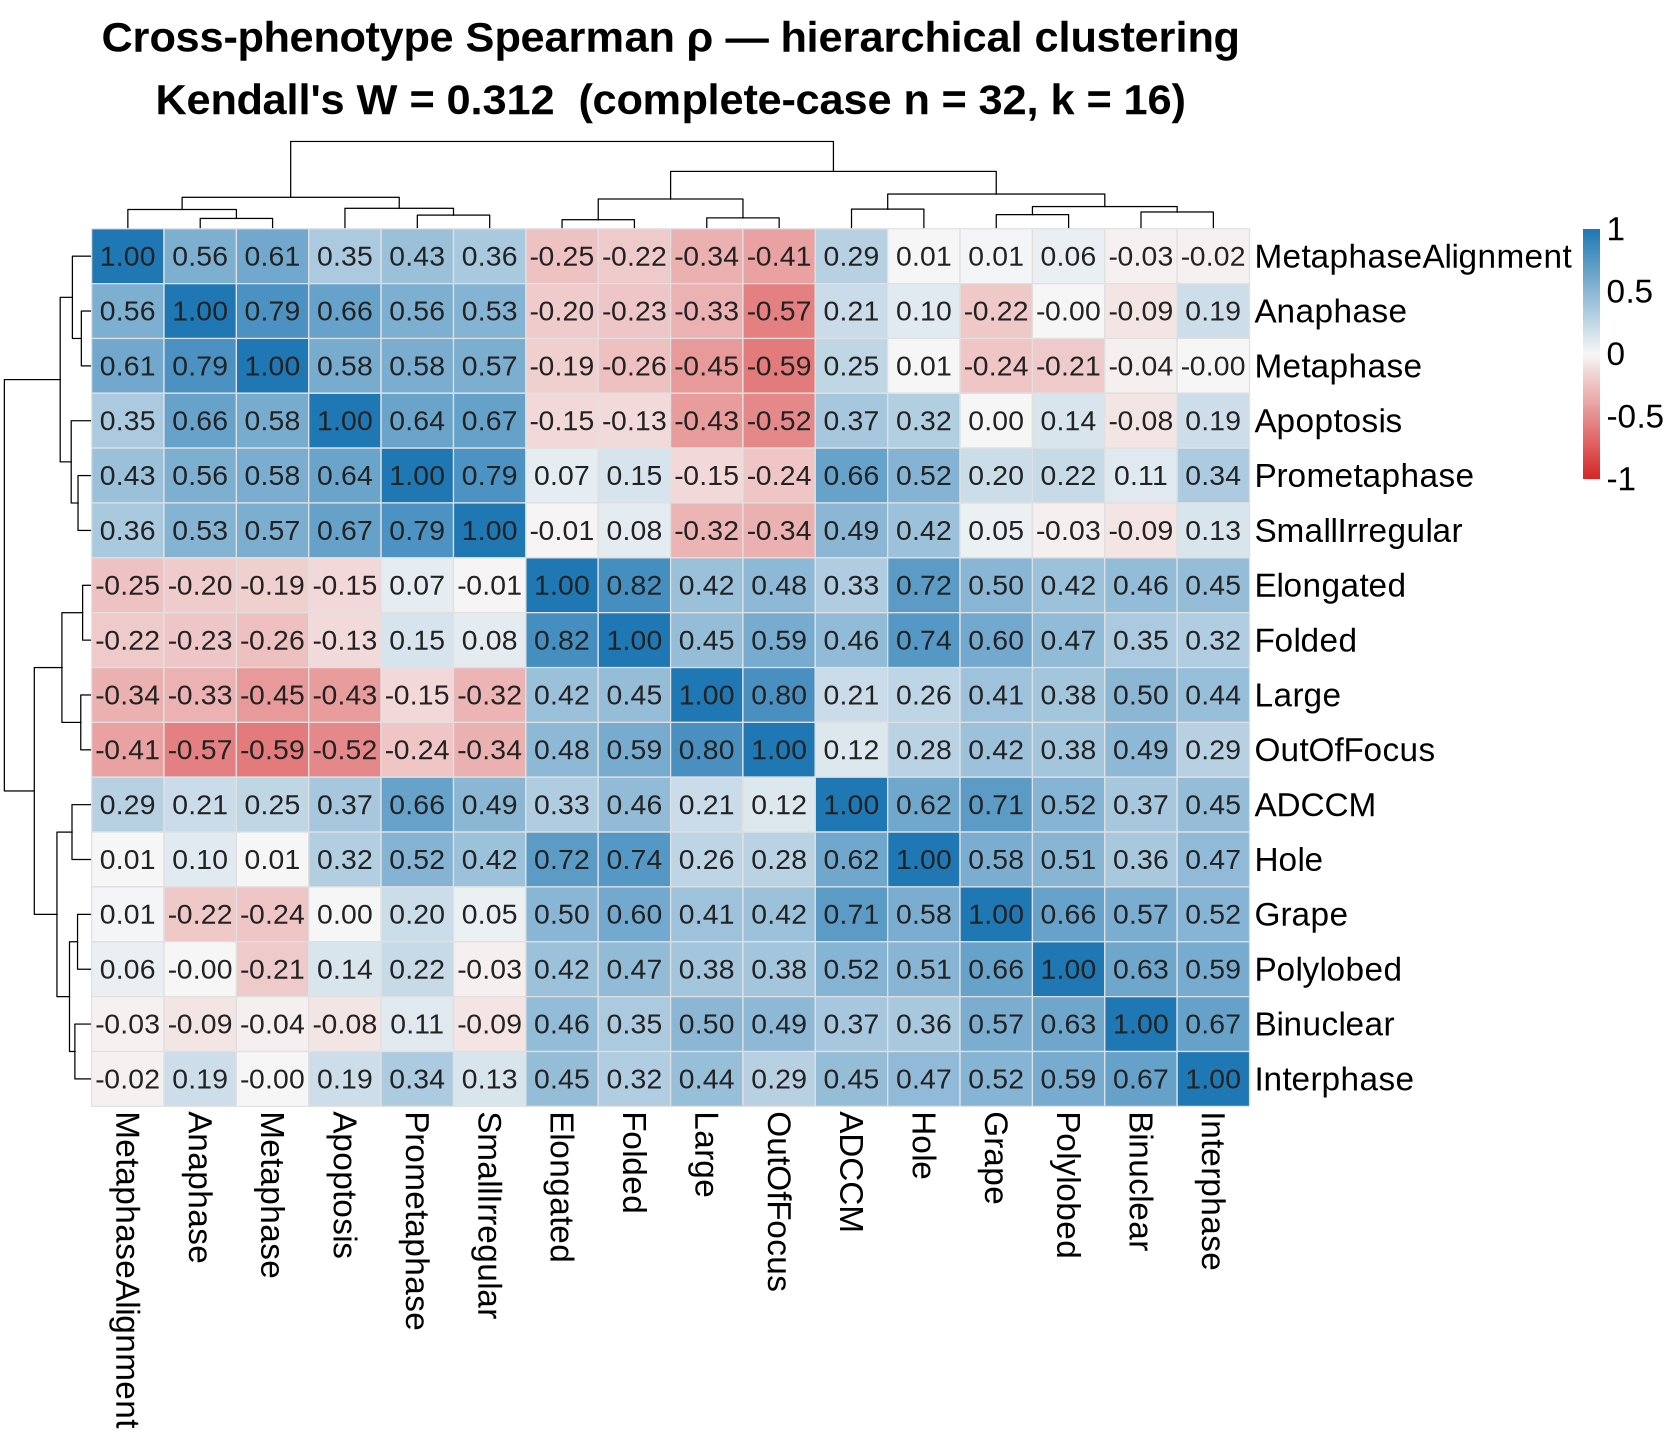

[shuffled] Saved -> /home/erikserrano/Projects/buscar/notebooks/3.mitocheck-analysis/plots/all-plots/gene-ranking-relationships/shuffled_profile_rank_consistency_clustermap.png


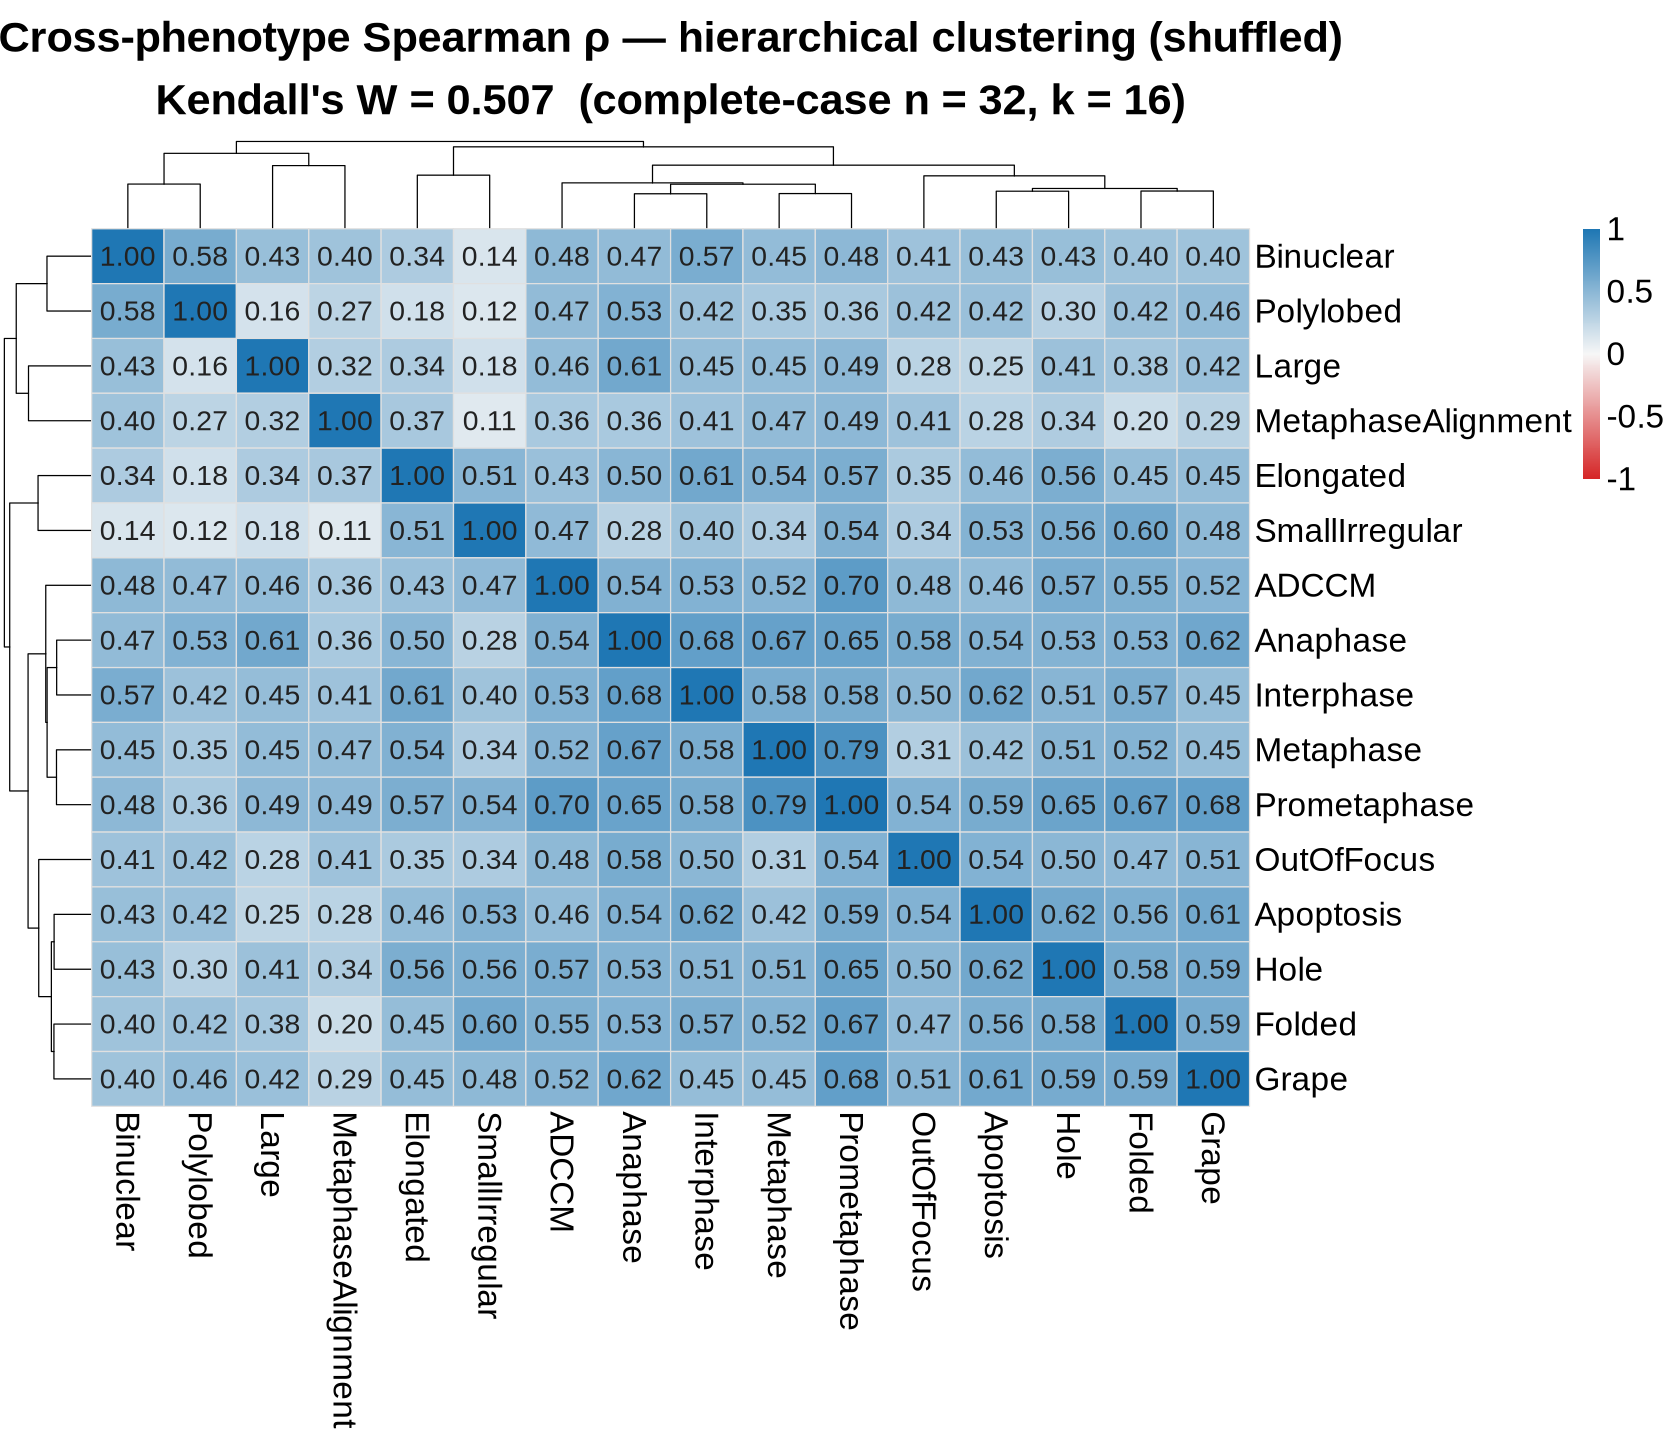

In [18]:
# options for rendering the figure larger
height <- 12
width <- 14
options(repr.plot.width = width, repr.plot.height = height)

save_corr_clustermap <- function(consistency, file_name, title_suffix = '', label = 'original') {
  corr_clean <- consistency$corr_matrix
  corr_clean[is.na(corr_clean)] <- 0

  anno_numbers <- ifelse(is.na(consistency$corr_matrix), 'NA', sprintf('%.2f', consistency$corr_matrix))
  dim(anno_numbers) <- dim(consistency$corr_matrix)

  pheat <- pheatmap(
    corr_clean,
    color = colorRampPalette(c('#d62728', '#f7f7f7', '#1f77b4'))(256),
    breaks = seq(-1, 1, length.out = 257),
    cluster_rows = TRUE,
    cluster_cols = TRUE,
    display_numbers = anno_numbers,
    number_color = '#222222',
    fontsize = 20,
    fontsize_row = 20,
    fontsize_col = 20,
    fontsize_number = 17,
    border_color = '#e0e0e0',
    main = sprintf(
      "Cross-phenotype Spearman ρ — hierarchical clustering%s\nKendall's W = %s  (complete-case n = %d, k = %d)",
      title_suffix, consistency$w_label, consistency$n_subjects, consistency$k_raters
    )
  )

  out_path <- file.path(gene_rel_dir, file_name)
  png(out_path, width = 14, height = 14, units = 'in', res = 300)
  grid::grid.newpage()
  grid::grid.draw(pheat$gtable)
  dev.off()
  cat(sprintf('[%s] Saved -> %s\n', label, out_path))
}

save_corr_clustermap(
  orig_consistency,
  'profile_rank_consistency_clustermap.png',
  '',
  'original'
)

save_corr_clustermap(
  shuf_consistency,
  'shuffled_profile_rank_consistency_clustermap.png',
  ' (shuffled)',
  'shuffled'
)

The real data (W = 0.348) produced biologically coherent clusters  mitotic phenotypes (Prometaphase, Anaphase, Metaphase) grouped together with high positive correlations, while morphologically distinct states like Large and OutOfFocus showed negative correlations against the mitotic cluster. The shuffled data (W = 0.528) lost this entirely, collapsing into uniformly moderate positive correlations with no meaningful clustering structure and no negative correlations.

## Real vs Permutation Null

This section tests whether the observed concordance in gene rankings (Kendall's W) is driven by genuine biological signal or is simply a structural artifact of the data.

- **Real W**: concordance computed from the original gene rankings across all phenotypic states.
- **Permutation-null W**: concordance after randomly shuffling which gene receives which row of rankings (label permutation). This preserves each gene's rank profile but breaks the alignment between genes and profiles, destroying any real signal while keeping data structure intact.

**Interpretation:** if real W is much larger than the permutation null distribution, the observed agreement across phenotypes is unlikely to have arisen by chance.


In [19]:
# Compute Kendall's W (and chi-square p-value) from a complete-case rank matrix
compute_kendall_w_from_matrix <- function(rank_matrix_complete) {
  n_subjects <- nrow(rank_matrix_complete)
  k_raters <- ncol(rank_matrix_complete)

  if (n_subjects <= 1 || k_raters <= 1) {
    return(list(
      W = NA_real_,
      p_value = NA_real_,
      chi2_stat = NA_real_,
      n_subjects = n_subjects,
      k_raters = k_raters
    ))
  }

  row_rank_sums <- rowSums(rank_matrix_complete)
  S <- sum((row_rank_sums - mean(row_rank_sums))^2)
  W <- (12 * S) / (k_raters^2 * (n_subjects^3 - n_subjects))

  chi2_stat <- k_raters * (n_subjects - 1) * W
  p_value <- pchisq(chi2_stat, df = n_subjects - 1, lower.tail = FALSE)

  list(
    W = W,
    p_value = p_value,
    chi2_stat = chi2_stat,
    n_subjects = n_subjects,
    k_raters = k_raters
  )
}

In [20]:
# Build the complete-case rank matrix from the original data and compute observed W
R_real <- as.matrix(orig_bundle$rank_pivot_reranked)

real_stats <- compute_kendall_w_from_matrix(R_real)


In [21]:
# Permutation settings
set.seed(0)
n_permutations <- 5000

# Null model: for each phenotype column, independently shuffle which gene receives
# which rank. This keeps the within-phenotype rank distribution intact but destroys
# the cross-phenotype concordance signal -- the standard null for Kendall's W.
perm_W <- replicate(n_permutations, {
  R_perm <- apply(R_real, 2, sample, replace = FALSE)
  if (is.vector(R_perm)) R_perm <- matrix(R_perm, ncol = ncol(R_real))
  compute_kendall_w_from_matrix(R_perm)$W
})

perm_W <- perm_W[!is.na(perm_W)]
empirical_p_real <- if (length(perm_W) > 0) mean(perm_W >= real_stats$W) else NA_real_
z_vs_perm <- if (length(perm_W) > 1 && sd(perm_W) > 0) (real_stats$W - mean(perm_W)) / sd(perm_W) else NA_real_

summary_tbl <- tibble::tibble(
  comparison = c('real', 'perm_null_mean', 'perm_null_sd', 'empirical_p_real_vs_perm', 'zscore_real_vs_perm'),
  value = c(
    real_stats$W,
    ifelse(length(perm_W) > 0, mean(perm_W), NA_real_),
    ifelse(length(perm_W) > 1, sd(perm_W), NA_real_),
    empirical_p_real,
    z_vs_perm
  )
)

print(summary_tbl)

summary_out <- file.path(gene_rel_dir, 'kendall_w_real_permutation_summary.csv')
readr::write_csv(summary_tbl, summary_out)
cat(sprintf('Saved -> %s\n', summary_out))


# A tibble: 5 × 2
  comparison                 value
  <chr>                      <dbl>
1 real                      0.312 
2 perm_null_mean            0.0629
3 perm_null_sd              0.0156
4 empirical_p_real_vs_perm  0     
5 zscore_real_vs_perm      16.0   
Saved -> /home/erikserrano/Projects/buscar/notebooks/3.mitocheck-analysis/plots/all-plots/gene-ranking-relationships/kendall_w_real_permutation_summary.csv


Saved -> /home/erikserrano/Projects/buscar/notebooks/3.mitocheck-analysis/plots/all-plots/gene-ranking-relationships/kendall_w_permutation_null_histogram.png
Saved -> /home/erikserrano/Projects/buscar/notebooks/3.mitocheck-analysis/plots/all-plots/gene-ranking-relationships/profile_specificity_real.csv


profile,mean_rho_real
<chr>,<dbl>
OutOfFocus,0.07786053
MetaphaseAlignment,0.09274043
Metaphase,0.09403146
Large,0.12399872
Anaphase,0.12967028
Apoptosis,0.17349029
SmallIrregular,0.21906788
Elongated,0.25745792
Binuclear,0.27852778


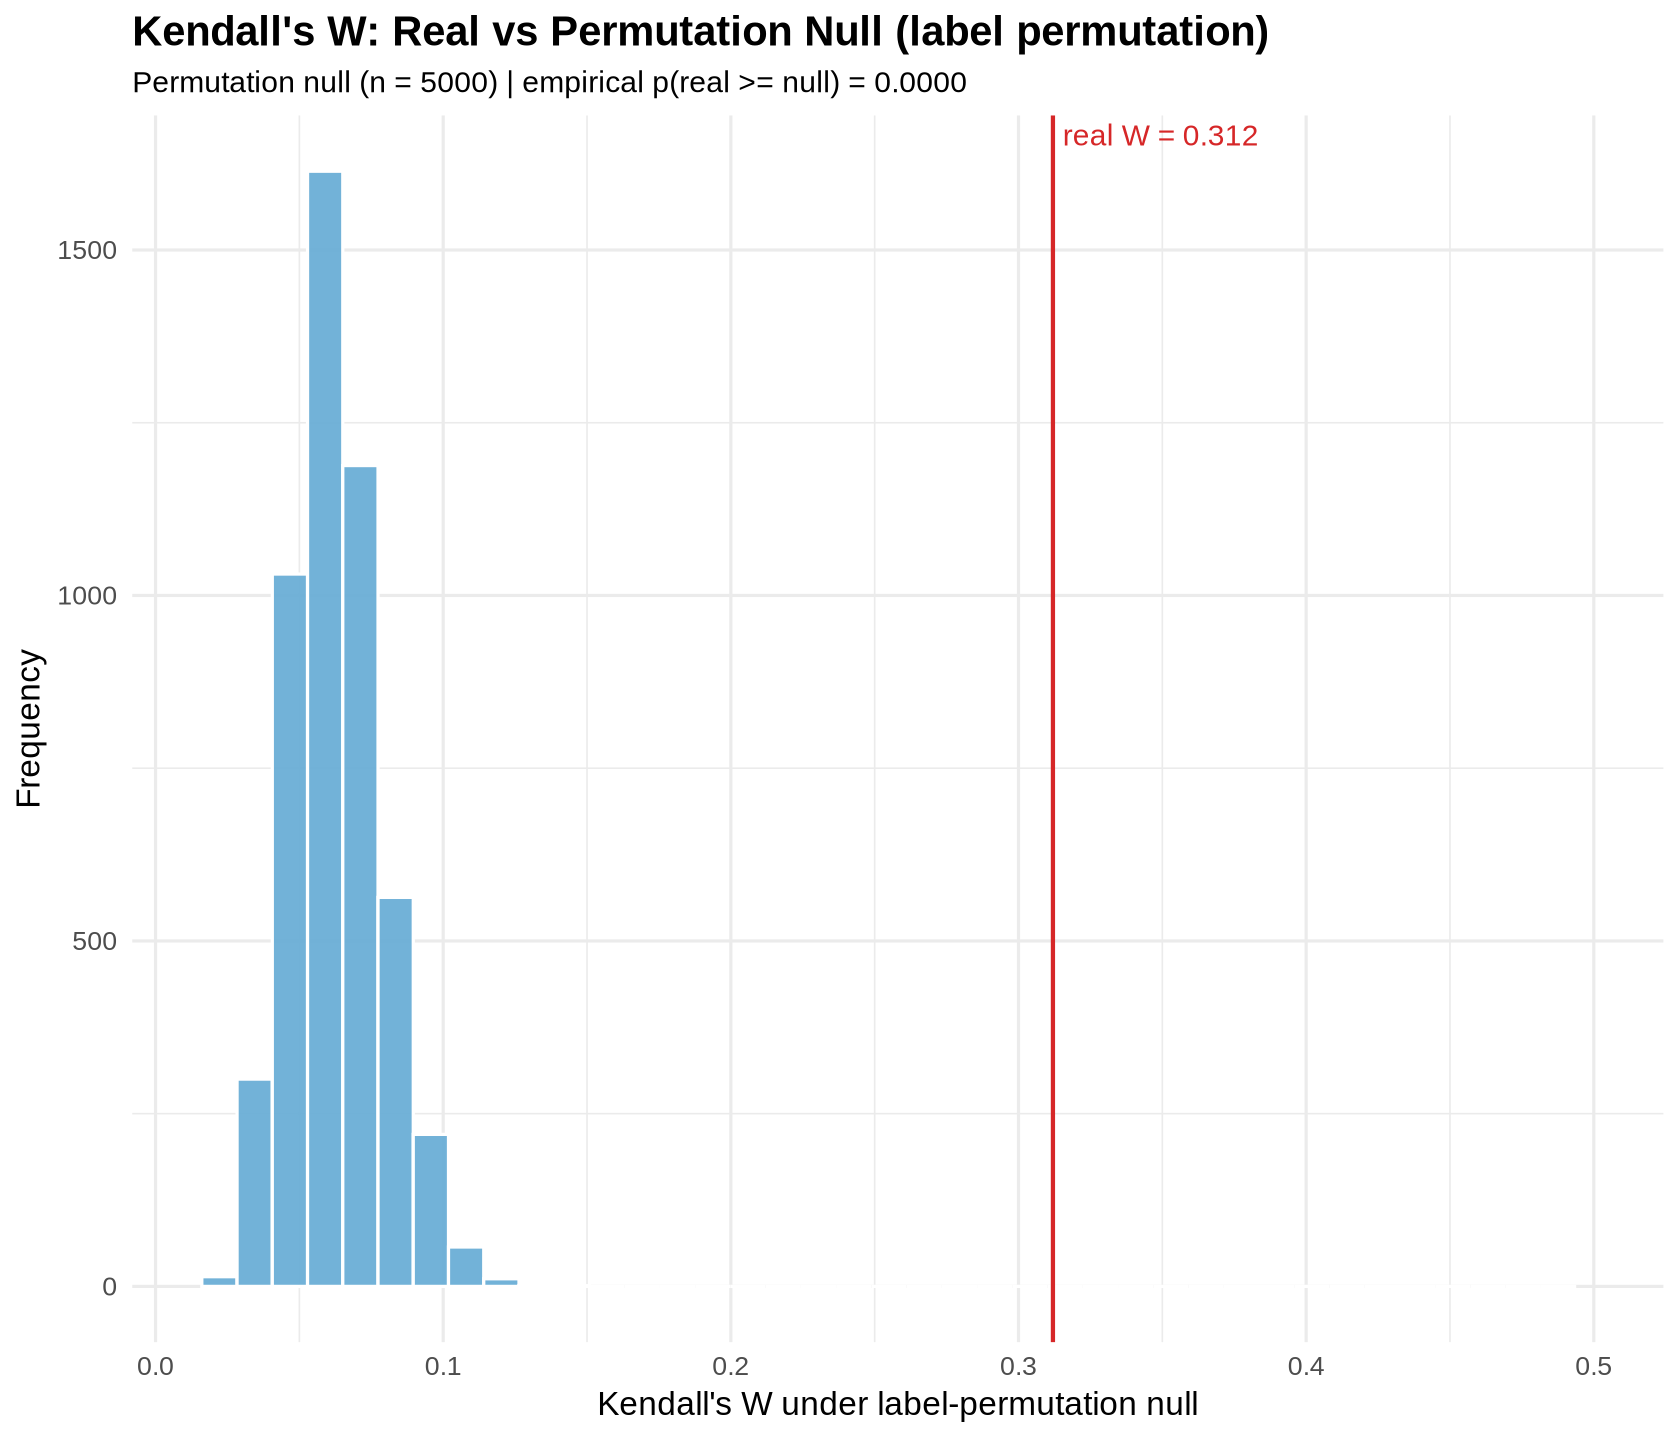

In [22]:
# Plot the permutation-null distribution with the real W as a reference line
plot_df <- tibble::tibble(W = perm_W)

p_perm <- ggplot(plot_df, aes(x = W)) +
  geom_histogram(bins = 40, fill = '#6baed6', color = 'white', alpha = 0.95) +
  geom_vline(xintercept = real_stats$W, color = '#d62728', linewidth = 1.2) +
  annotate('text', x = real_stats$W, y = Inf, label = sprintf('real W = %.3f', real_stats$W), vjust = 1.5, hjust = -0.05, color = '#d62728', size = 6.3) +
  scale_x_continuous(limits = c(NA, 0.5)) +
  labs(
    title = "Kendall's W: Real vs Permutation Null (label permutation)",
    subtitle = sprintf('Permutation null (n = %d) | empirical p(real >= null) = %s', n_permutations, ifelse(is.na(empirical_p_real), 'NA', sprintf('%.4f', empirical_p_real))),
    x = "Kendall's W under label-permutation null",
    y = 'Frequency'
  ) +
  theme_minimal(base_size = 20) +
  theme(
    plot.title = element_text(face = 'bold', size = 25),
    plot.subtitle = element_text(size = 18)
  )

perm_plot_out <- file.path(gene_rel_dir, 'kendall_w_permutation_null_histogram.png')
ggsave(perm_plot_out, p_perm, width = 11, height = 7, dpi = 300, bg = 'white')
cat(sprintf('Saved -> %s\n', perm_plot_out))

print(p_perm)

# Summarize phenotype specificity as mean off-diagonal Spearman correlation per profile
# (real data only -- uses the correlation matrices computed in Analysis 2).
profile_specificity <- tibble::tibble(profile = colnames(orig_consistency$corr_matrix)) %>%
  mutate(
    mean_rho_real = sapply(profile, function(p) {
      v <- orig_consistency$corr_matrix[p, setdiff(colnames(orig_consistency$corr_matrix), p)]
      mean(v, na.rm = TRUE)
    })
  ) %>%
  arrange(mean_rho_real)

spec_out <- file.path(gene_rel_dir, 'profile_specificity_real.csv')
readr::write_csv(profile_specificity, spec_out)
cat(sprintf('Saved -> %s\n', spec_out))

profile_specificity

The histogram shows the distribution of Kendall's W across 5000 permutations where gene-to-phenotype label assignments were randomly shuffled, with the real W (red line, 0.348) plotted against this null. The null distribution is tightly centered below 0.1 with zero overlap with the real W, yielding an empirical p = 0.0000.

Genes sharing a morphological phenotype label are far more concordant in how they rank other perturbations than any random label grouping across 5000 permutations, confirming confirming that morphological phenotype labels capture biologically meaningful relationships between gene perturbations
